In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os

os.chdir("/home/tsternal/phd/WeatherExtremes2")  # adjust

from src.utils.utils import SEASON_BOUNDS

In [2]:
def plot_exceedances(exceedances):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(15, 6))
    plt.imshow(exceedances, aspect='auto', cmap='Reds', interpolation='none', vmin=0, vmax=1)
    plt.xlabel('Day of Year')
    plt.ylabel('Year')
    plt.title('Exceedances (1 = exceedance, 0 = no exceedance)')
    plt.colorbar(label='Exceedance')
    plt.show()
    
def get_exceedances(data, percentiles, perc_id=0):
    exceedances = np.empty_like(data)
    for year in range(exceedances.shape[0]):
        for doy in range(365):
            exceedances[year][doy] = data[year][doy] > percentiles[doy][perc_id]
    return exceedances

def count_ex_per_period(exceedances):
    # TODO: approximate - use actual dates instead
    start, end = SEASON_BOUNDS[2] # JUN-AUG
    return exceedances[:,start:end+1].sum(axis=1)

def plot_count(data_label_list, title):
    """
    Plots one or more count series, each with its label.

    Args:
        data_label_list: List of (data, label) tuples.
                         Each data is a 1D array-like, label is a string.
    """
    plt.figure(figsize=(15, 6))
    colors = ['b', 'r', 'g', 'm', 'c', 'k']  # Add more as needed
    for i, (count, label) in enumerate(data_label_list):
        color = colors[i % len(colors)]
        plt.plot(count, marker='o', linestyle='-', color=color, label=label)
    plt.title(title)
    plt.xlabel('Year')
    plt.ylabel('Number of Exceedances (JUN-AUG)')
    plt.grid(True)
    if len(data_label_list) > 1:
        plt.legend()
    plt.show()
    
def get_percentile(data, percentile, day_id, year_start=0, year_end=30):
    ref_doy_data = data[year_start:year_end, day_id]
    percentile = np.percentile(ref_doy_data, percentile)
    return percentile

def get_percentile_with_boosting(data, percentile, day_id, year_start=0, year_end=30, boosting=1):
    half = boosting // 2
    start_doy = max(0, day_id - half)
    end_doy = min(364, day_id + half)
    ref_doy_data = data[year_start:year_end, start_doy:end_doy+1].flatten()
    percentile = np.percentile(ref_doy_data, percentile)
    return percentile


def aggregate(data, agg_window):
    """
    Aggregates a 2D array along columns with a centered moving average of window size agg_window.

    Args:
        data (np.ndarray): 2D array. Axis 1 is aggregated.
        agg_window (int): Odd integer for window size.

    Returns:
        np.ndarray: Aggregated data, same shape as input.
    """
    assert agg_window >= 1 and agg_window % 2 == 1, "agg_window must be odd and >= 1"
    rows, cols = data.shape
    half = agg_window // 2
    out = np.empty_like(data)
    for i in range(rows):
        for j in range(cols):
            start = max(0, j - half)
            end = min(cols, j + half + 1)
            out[i, j] = np.mean(data[i, start:end])
    return out

In [5]:
"""
Test different percentiles
"""
def vary_percentiles(data, percs=[90, 95, 99], agg_window = 1):
    agg_data = aggregate(data, agg_window)
    percentiles = [[get_percentile(agg_data, perc, doy) for perc in percs] for doy in range(365)]

    counts = []
    for perc_id, perc in enumerate(percs):
        exceedances = get_exceedances(agg_data, percentiles, perc_id)
        plot_exceedances(exceedances)
        summer_exceedances_count = count_ex_per_period(exceedances)
        counts.append( (summer_exceedances_count, perc) )
    plot_count(counts, "Different Percentiles")


"""
Test different aggregation windows
"""
def vary_agg_wind(data, agg_wind=[3,5,7,15,21]):
    percs = [90, 95, 99]
    counts = []

    for agg_window in agg_wind:
        agg = aggregate(data, agg_window)
        percentiles = [[get_percentile(agg, perc, doy) for perc in percs] for doy in range(365)]
        exceedances = get_exceedances(agg, percentiles, perc_id=0)
        plot_exceedances(exceedances)
        summer_exceedances_count = count_ex_per_period(exceedances)
        counts.append( (summer_exceedances_count, agg_window) )
    plot_count(counts, "Different Aggregation Windows")

"""
Test different boosting windows
"""
def vary_boost_wind(data, boost_wind=[1, 3, 5, 7, 15, 21]):
    percs = [90, 95, 99]
    perc_id = 1

    counts = []
    for boost in boost_wind:
        percentiles = [[get_percentile_with_boosting(data, perc, doy, boosting=boost) for perc in percs] for doy in range(365)]
        exceedances = get_exceedances(data, percentiles, perc_id)
        plot_exceedances(exceedances)
        summer_exceedances_count = count_ex_per_period(exceedances)
        counts.append( (summer_exceedances_count, boost) )
    plot_count(counts, "Different Boosting Windows")
    
"""
Linear regression on a provided array of points: returns slope
"""
def get_slope(arr):
    y = np.array(arr)
    x = np.arange(len(y))
    if len(x) > 1:
        slope, intercept = np.polyfit(x, y, 1)
    else:
        slope = np.nan  # Not enough points to fit a line
    return slope


# PERCENTILE VS AGG_WINDOW SURFACE

In [20]:
def compute_slopes_vary_perc_agg_wind(data, agg_windows=[1,3,5,7,9,11,13,15,17,19,21], percs=list(range(90, 100))):
    counts = {}
    for agg_window in agg_windows:
        agg = aggregate(data, agg_window)
        percentiles = [[get_percentile(agg, perc, doy) for perc in percs] for doy in range(365)]
        for perc_id, perc in enumerate(percs):
            exceedances = get_exceedances(agg, percentiles, perc_id=perc_id)
            summer_exceedances_count = count_ex_per_period(exceedances)
            counts[(perc_id, agg_window)] = (summer_exceedances_count, get_slope(summer_exceedances_count))

    # Extract values for plotting
    perc_ids = sorted(set(k[0] for k in counts.keys()))
    agg_windows = sorted(set(k[1] for k in counts.keys()))
    Z = np.zeros((len(perc_ids), len(agg_windows)))

    for i, pid in enumerate(perc_ids):
        for j, awin in enumerate(agg_windows):
            Z[i, j] = counts[(pid, awin)][1]
    
    return Z, agg_windows, percs


def compute_slopes_vary_boost_wind_and_ref_per(data, boost_windows=[1,3,5,7], ref_periods=[(start,start+30) for start in [0,10,20,30]]):
    counts = {}
    agg_window = 3
    percs = [95]
    for boost in boost_windows:
        agg = aggregate(data, agg_window)
        for (year_start, year_end) in ref_periods:
            percentiles = [[get_percentile_with_boosting(agg, perc, doy, boosting=boost, year_start=year_start, year_end=year_end) for perc in percs] for doy in range(365)]
            for perc_id, perc in enumerate(percs):
                exceedances = get_exceedances(agg, percentiles, perc_id=perc_id)
                summer_exceedances_count = count_ex_per_period(exceedances)
                counts[(boost, (year_start, year_end))] = (summer_exceedances_count, get_slope(summer_exceedances_count))

    # Extract values for plotting
    boost_windows = sorted(set(k[0] for k in counts.keys()))
    ref_periods = sorted(set(k[1] for k in counts.keys()))
    Z = np.zeros((len(boost_windows), len(ref_periods)))

    for i, boost in enumerate(boost_windows):
        for j, ref_period in enumerate(ref_periods):
            Z[i, j] = counts[(boost, ref_period)][1]
    
    return Z, boost_windows, ref_periods

def compute_slopes_vary_perc_boost(data, boost_windows=[1,3,5,7], percs=list(range(90, 100))):
    counts = {}
    agg = aggregate(data, 5)
    
    for boost in boost_windows:
        percentiles = [[get_percentile_with_boosting(agg, perc, doy, boosting=boost) for perc in percs] for doy in range(365)]
        for perc_id, perc in enumerate(percs):
            exceedances = get_exceedances(agg, percentiles, perc_id=perc_id)
            summer_exceedances_count = count_ex_per_period(exceedances)
            counts[(perc_id, boost)] = (summer_exceedances_count, get_slope(summer_exceedances_count))

    # Extract values for plotting
    perc_ids = sorted(set(k[0] for k in counts.keys()))
    agg_windows = sorted(set(k[1] for k in counts.keys()))
    Z = np.zeros((len(perc_ids), len(agg_windows)))

    for i, pid in enumerate(perc_ids):
        for j, awin in enumerate(agg_windows):
            Z[i, j] = counts[(pid, awin)][1]
    
    return Z, agg_windows, percs
        
def plot_trend_surface(surface, agg_windows_or_boost_window, percs_or_ref_periods, labels=['Aggregation Window', 'Percentile'], title =""):
    """
    Plot a 3D surface for slope trends over a grid defined by agg_windows/boost_window (X)
    and percs/ref_periods (Y). Handles both numeric and tuple-based/categorical Y labels.
    """
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    # Convert tuple-based or string period Y axis to string: allow (str, str) tuples as well.
    if len(percs_or_ref_periods) > 0 and (isinstance(percs_or_ref_periods[0], tuple) or isinstance(percs_or_ref_periods[0], list)):
        percs_or_ref_periods = [f"{1960+a}-{1960+b}" for (a, b) in percs_or_ref_periods]
    percs_or_ref_periods_ids = list(range(len(percs_or_ref_periods)))
    # Map perc_ids to actual perc values (for annotation only; plotting Y is categorical/int)
    percs_or_ref_periods_id_to_value = {i: perc for i, perc in enumerate(percs_or_ref_periods)}

    # Ensure agg_windows values are integers
    agg_windows_or_boost_window_int = [int(aw) for aw in agg_windows_or_boost_window]

    X, Y = np.meshgrid(agg_windows_or_boost_window_int, percs_or_ref_periods_ids)

    fig = plt.figure(figsize=(20, 12))
    if title:
        fig.suptitle(title, fontsize=20)

    view_angles = [
        (30, 45),   # Default
        (120, 30),  # Top-down side
        (210, 60),  # Rear angled
        (45, 90)    # Overhead/top
    ]

    # Is Y axis categorical (labels/strings), and how to map for plotting
    is_categorical = isinstance(percs_or_ref_periods[0], str)
    y_labels = list(percs_or_ref_periods) if is_categorical else None

    for i, (azim, elev) in enumerate(view_angles, 1):
        ax = fig.add_subplot(2, 2, i, projection='3d')

        # For the 3D plot, Y always uses the numeric indices (easier for mpl 3D mesh),
        # then ticklabels map back to their label
        surf = ax.plot_surface(
            X, Y, surface,
            cmap='viridis', alpha=0.7, edgecolor='none'
        )

        # Set yticks and yticklabels if categorical
        if is_categorical:
            ax.set_yticks(percs_or_ref_periods_ids)
            ax.set_yticklabels(y_labels)

        # Mark points on the surface for emphasis
        ax.scatter(
            X.ravel(),
            Y.ravel(),
            surface.ravel(),
            c='k', marker='o', s=30, label='Data Points'
        )

        # Annotate each point with the slope value
        # Use Y indices for positioning, but label with string if categorical
        for x, y_idx, z in zip(X.ravel(), Y.ravel(), surface.ravel()):
            # Annotate using the corresponding label if categorical
            y_label = y_labels[y_idx] if is_categorical else f"{percs_or_ref_periods_id_to_value[y_idx]}"
            ax.text(x, y_idx, z, f"{z:.2f}", color="black", fontsize=8, ha='left', va='bottom')

        ax.set_xlabel(labels[0])
        ax.set_ylabel(labels[1])
        ax.set_zlabel('Slope')
        ax.set_title(title)
        ax.view_init(elev=elev, azim=azim)
        ax.set_xticks(agg_windows_or_boost_window_int)
        ax.set_xticklabels([str(aw) for aw in agg_windows_or_boost_window_int])
        if i == 1:
            fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Slope')

    plt.tight_layout()
    plt.show()

In [ ]:
cities = ['vienna', 'zurich', 'beijing', 'nyc', 'neg_trend']
var = '2m_temperature'
for city in cities:
    zarr = f"{city}_weatherbench2_{var}_daily_mean.zarr"
    data = xr.open_zarr(f'data/preprocessed/{zarr}')[var]
    data = data.values.reshape(63,365) - 273.15  # Convert from Kelvin to Celsius
    
    surface, agg_windows, percs = compute_slopes_vary_perc_agg_wind(data)
    plot_trend_surface(surface, agg_windows, percs, title=f"{var} trends for {city} for varying Aggregation Windows and Percentiles")
    
    surface, agg_windows, percs = compute_slopes_vary_perc_boost(data, boost_windows=[1,3,5,7,9,11,13,15,21,31])
    plot_trend_surface(surface, agg_windows, percs, labels=['Boosting Window', 'Percentile'], title=f"{var} trends for {city} for varying Boosting Windows and Percentiles")

/tmp/ipykernel_805334/3996605912.py:144: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


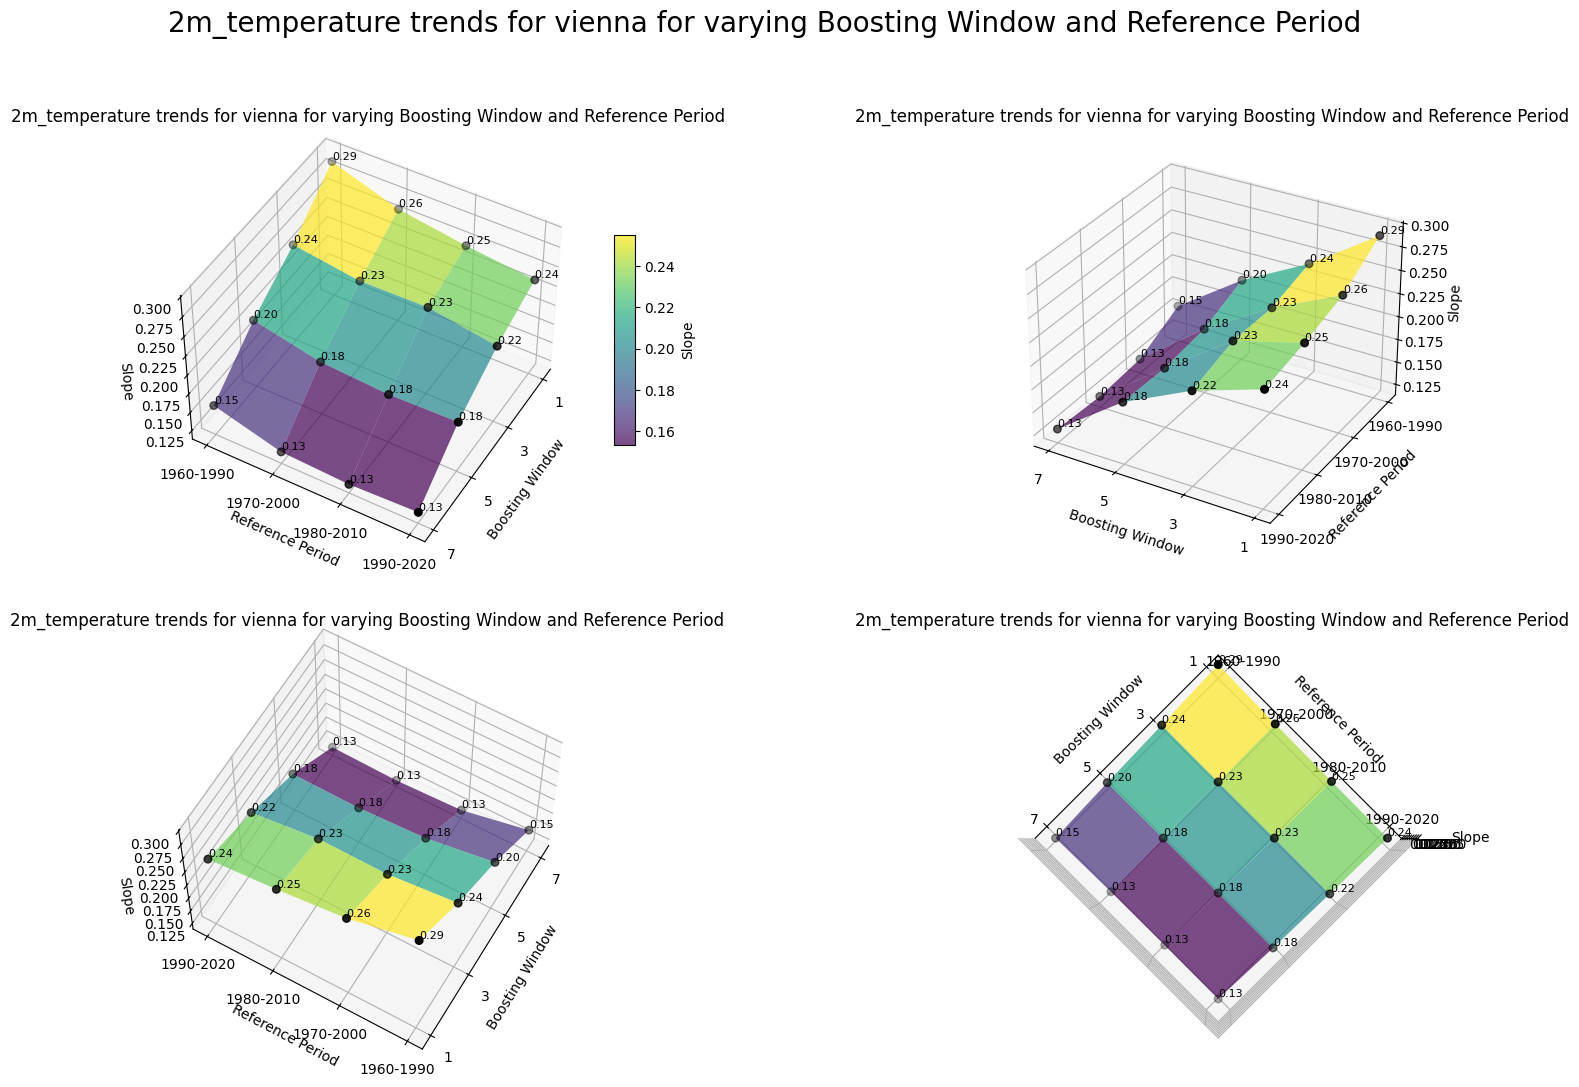

In [21]:

# cities = ['vienna', 'zurich', 'beijing', 'nyc', 'neg_trend']
cities = ['vienna']
var = '2m_temperature'
for city in cities:
    zarr = f"{city}_weatherbench2_{var}_daily_mean.zarr"
    data = xr.open_zarr(f'data/preprocessed/{zarr}')[var]
    data = data.values.reshape(63,365) - 273.15  # Convert from Kelvin to Celsius
    
    surface, boosting_windows, referece_periods = compute_slopes_vary_boost_wind_and_ref_per(data)
    plot_trend_surface(surface, boosting_windows, referece_periods, title=f"{var} trends for {city} for varying Boosting Window and Reference Period", labels=["Boosting Window", "Reference Period"])

/tmp/ipykernel_805334/3996605912.py:144: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


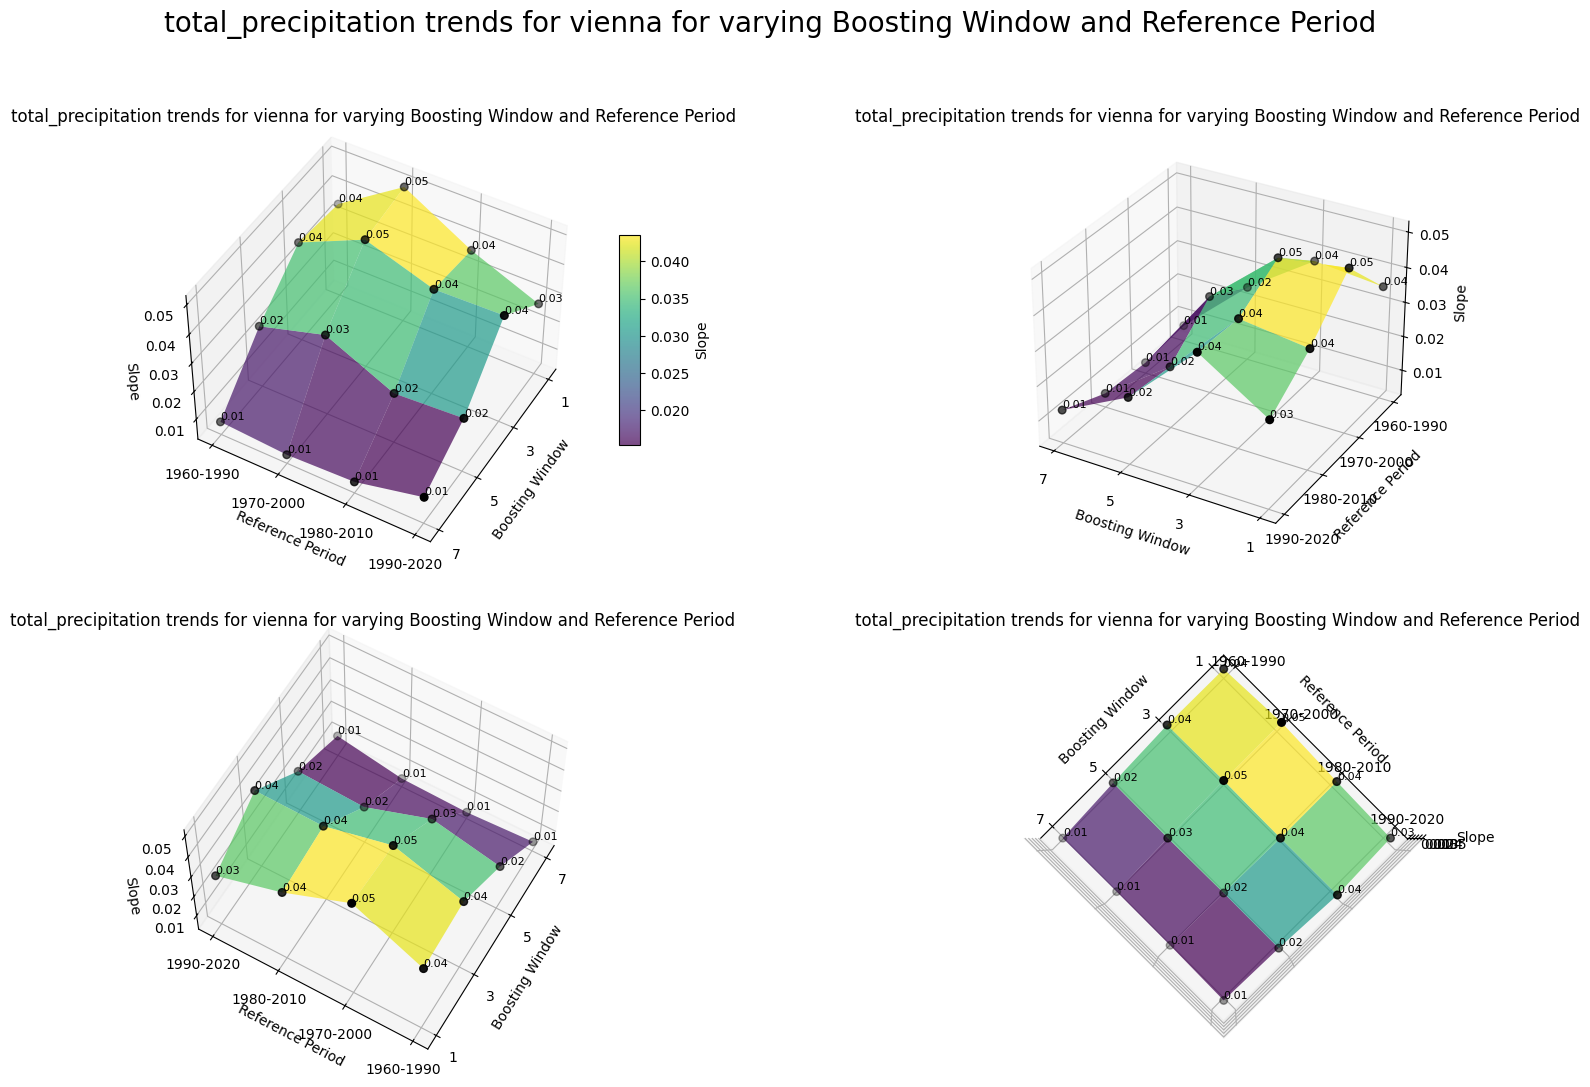

In [22]:
# cities = ['vienna', 'zurich', 'nyc']
cities = ['vienna']
var = 'total_precipitation'

for city in cities:
    zarr = f"{city}_weatherbench2_{var}_daily_sum.zarr"
    data = xr.open_zarr(f'data/preprocessed/{zarr}')[var]
    data = data.values.reshape(63,365)
    
    # # Vary Perc Agg Wind    
    # surface, agg_windows, percs = compute_slopes_vary_perc_agg_wind(data)
    # plot_trend_surface(surface, agg_windows, percs, title=f"{var} trends for {city} for varying Aggregation Windows and Percentiles")
    # # Vary Perc Boost
    # surface, agg_windows, percs = compute_slopes_vary_perc_boost(data, boost_windows=[1,3,5,7,9,11,13,15,21,31])
    # plot_trend_surface(surface, agg_windows, percs, labels=['Boosting Window', 'Percentile'], title=f"{var} trends for {city} for varying Boosting Windows and Percentiles")
    
    surface, boosting_windows, referece_periods = compute_slopes_vary_boost_wind_and_ref_per(data)
    plot_trend_surface(surface, boosting_windows, referece_periods, title=f"{var} trends for {city} for varying Boosting Window and Reference Period", labels=["Boosting Window", "Reference Period"])

[[np.float32(8.777652)], [np.float32(8.760004)], [np.float32(8.742357)], [np.float32(8.741469)], [np.float32(9.276875)], [np.float32(9.350223)], [np.float32(10.323832)], [np.float32(10.323832)], [np.float32(11.003838)], [np.float32(11.003838)], [np.float32(11.405173)], [np.float32(11.405173)], [np.float32(11.405173)], [np.float32(11.192284)], [np.float32(10.936989)], [np.float32(7.8772383)], [np.float32(10.2910595)], [np.float32(11.777902)], [np.float32(11.777902)], [np.float32(11.777902)], [np.float32(11.777902)], [np.float32(12.1848545)], [np.float32(12.078812)], [np.float32(12.078812)], [np.float32(12.026254)], [np.float32(12.814202)], [np.float32(12.805765)], [np.float32(12.805765)], [np.float32(12.805765)], [np.float32(12.805765)], [np.float32(11.896114)], [np.float32(9.41222)], [np.float32(11.443531)], [np.float32(13.686713)], [np.float32(13.768168)], [np.float32(13.768168)], [np.float32(13.768168)], [np.float32(13.768168)], [np.float32(12.237993)], [np.float32(11.57849)], [np.fl

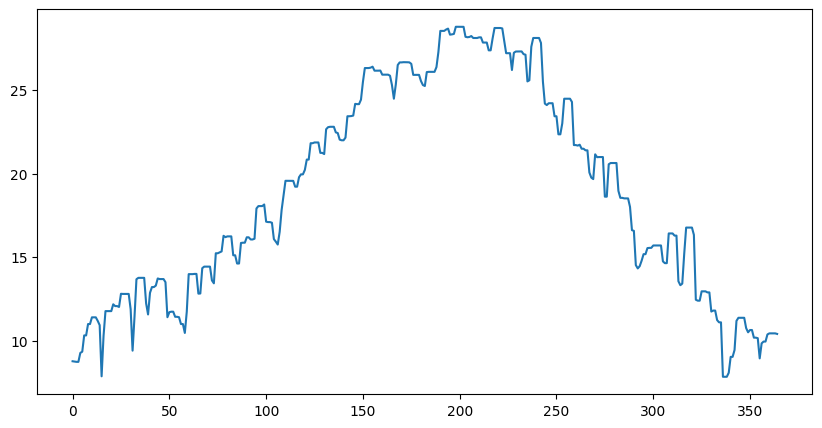

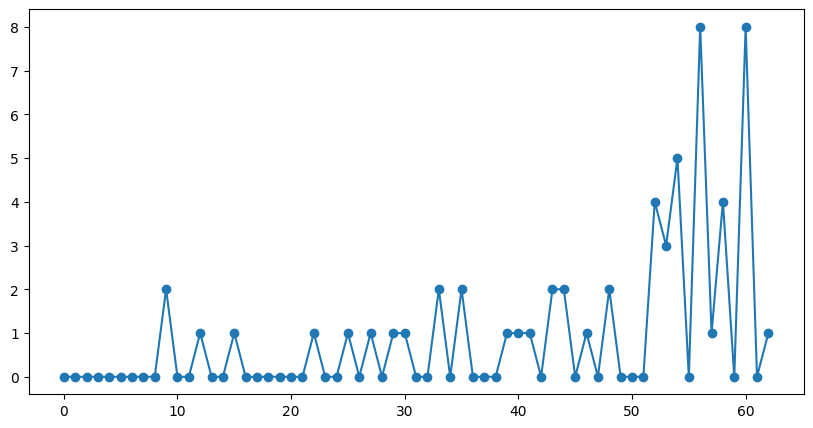

In [10]:
# cities = ['vienna', 'zurich', 'beijing', 'nyc']
city = 'vienna'
zarr = f"{city}_weatherbench2_2m_temperature_daily_mean.zarr"
var = '2m_temperature'
data = xr.open_zarr(f'data/preprocessed/{zarr}')['2m_temperature']
data = data.values.reshape(63,365) - 273.15  # Convert from Kelvin to Celsius

# agg = aggregate(data, 5)
agg = data.copy()

percs = []
for doy in range(365):
    # percs.append([get_percentile_with_boosting(agg, 99.9, doy, 2, 41, boosting=5)])
    percs.append([get_percentile_with_boosting(agg, 99.9, doy, 22, 51, boosting=5)])
print(percs)


plt.figure(figsize=(10, 5))
plt.plot(range(365), percs, label='90th percentile (boosted)')


ex = get_exceedances(agg, percs)
ex_count = count_ex_per_period(ex)
plt.figure(figsize=(10, 5))
plt.plot(range(63), ex_count, marker='o')


x = np.arange(len(ex_count))
coeffs = np.polyfit(x, ex_count, 1)  # Linear fit: coeffs[0] is slope, coeffs[1] is intercept
trend_line = np.polyval(coeffs, x)
print("Slope:", coeffs[0])
print("X-intercept:", -coeffs[1] / coeffs[0] if coeffs[0] != 0 else "undefined")